# GARCH Marginal Modelling
  
**Stage:** Marginal modelling — fit univariate GJR-GARCH(1,1)-t to each asset

## Objectives
1. Fit AR(1)-GJR-GARCH(1,1) with Student-t innovations to each asset
2. Diagnose model fit — Ljung-Box on residuals and squared residuals
3. Plot conditional volatility for each asset
4. Extract standardised residuals and verify they are approximately i.i.d.
5. Apply Probability Integral Transform (PIT) to obtain uniform marginals
6. Verify uniform marginals via histogram and KS test
7. Save uniform marginals for input to Notebook 03 — Copula Fitting
 


In [21]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as stats_scipy
from scipy.stats import kstest, uniform
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model

from src.garch_utils import fit_gjr_garch, fit_all_marginals, extract_uniforms, garch_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [22]:
# Load clean prices and recompute returns
prices = pd.read_csv('../data/raw/prices.csv', index_col='Date', parse_dates=True)
returns = np.log(prices / prices.shift(1)).dropna()

# Train/test split
train = returns.loc[:'2022-12-31']
test  = returns.loc['2023-01-01':]

print(f"Train: {train.index[0].date()} to {train.index[-1].date()} ({len(train)} obs)")
print(f"Test:  {test.index[0].date()} to {test.index[-1].date()} ({len(test)} obs)")

Train: 2010-01-05 to 2022-12-30 (3281 obs)
Test:  2023-01-03 to 2024-12-31 (505 obs)


### Model Specification

We fit an AR(1)-GJR-GARCH(1,1) model with Student-t innovations to each asset.

**Mean equation — AR(1)**

$$r_t = \mu + \phi \, r_{t-1} + \epsilon_t$$

Handles mild serial correlation in returns.

**Variance equation — GJR-GARCH(1,1)**

$$\sigma^2_t = \omega + \alpha \, \epsilon^2_{t-1} + \gamma \, \epsilon^2_{t-1} \, \mathbb{1}[\epsilon_{t-1} < 0] + \beta \, \sigma^2_{t-1}$$

Where $\mathbb{1}[\epsilon_{t-1} < 0] = 1$ if the previous shock was negative, 0 otherwise.  
The $\gamma$ term captures the **leverage effect** — negative shocks increase 
volatility more than positive shocks of the same magnitude.

**Innovation distribution — Student-t**

$$\epsilon_t = \sigma_t \, z_t, \qquad z_t \sim t_\nu$$

Handles fat tails in standardised residuals.  
The degrees of freedom parameter $\nu$ is estimated from the data.

### 1. Fit GARCH Models

In [23]:
garch_results = fit_all_marginals(train, dist='studentst')

Fitting GJR-GARCH for FTSE100...
  AIC: 8313.61  |  BIC: 8356.28

Fitting GJR-GARCH for GBPUSD...
  AIC: 5103.93  |  BIC: 5146.60

Fitting GJR-GARCH for Brent...
  AIC: 13294.77  |  BIC: 13337.44



### 2. Parameter Summary

In [18]:
for asset, res in garch_results.items():
    print(f"\n{'=' * 65}")
    print(f"Asset: {asset}")
    print(f"{'=' * 65}")
    summary = res['model_result'].summary()
    for table in summary.tables:
        print(table)
    print(f"\nAIC: {res['model_result'].aic:.4f}  |  BIC: {res['model_result'].bic:.4f}")


Asset: FTSE100
                            AR - GJR-GARCH Model Results                            
Dep. Variable:                      FTSE100   R-squared:                      -0.000
Mean Model:                              AR   Adj. R-squared:                 -0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -4149.81
Distribution:      Standardized Student's t   AIC:                           8313.61
Method:                  Maximum Likelihood   BIC:                           8356.28
                                              No. Observations:                 3280
Date:                      Thu, Mar 05 2026   Df Residuals:                     3278
Time:                              04:23:52   Df Model:                            2
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
-------------------------------------------------------------

### Parameter Interpretation

#### FTSE 100
- **Const / AR(1):** Both insignificant (p=0.184, p=0.886) — no meaningful 
  autocorrelation in FTSE returns, consistent with EDA findings
- $\omega$: Significant (p<0.001) — positive baseline variance confirmed
- $\alpha$: Essentially zero (p=1.000) — past squared shocks alone have 
  negligible direct effect on volatility
- **$\gamma$ = 0.2355, highly significant (p<0.001)** — strong leverage effect 
  confirmed. Negative shocks increase volatility roughly 0.24 units more than 
  positive shocks of equal magnitude. Classic equity behaviour
- **$\beta$ = 0.8457, highly significant** — high volatility persistence. 
  Shocks to volatility take considerable time to decay
- **$\nu$ = 6.75** — moderately fat tails. Significantly less than $\infty$ 
  (normal limit), confirming Student-t innovations were necessary

#### GBP/USD
- **Const / AR(1):** Both insignificant — returns are unpredictable in the mean
- $\omega$: Not significant (p=0.155) — baseline variance is low and noisy
- $\alpha$: Marginally insignificant — direct ARCH effect is weak
- **$\gamma$ = 0.0402, significant (p=0.002)** — leverage effect present but 
  weaker than FTSE, consistent with FX markets having less pronounced 
  asymmetry than equity markets
- **$\beta$ = 0.9427** — very high persistence, highest of the three assets. 
  GBP/USD volatility shocks are extremely long-lived
- **$\nu$ = 7.50** — similar tail thickness to FTSE

#### Brent Crude
- **Const:** Marginally insignificant (p=0.072) — slight positive drift
- **AR(1):** Marginally insignificant (p=0.100) — weak mean reversion
- $\alpha$ = 0.0431 — small but present ARCH effect
- **$\gamma$ = 0.0660, highly significant (p<0.001)** — leverage effect confirmed. 
  Smaller than FTSE but meaningful — negative oil price shocks amplify 
  volatility more than positive shocks
- **$\beta$ = 0.9139** — very high persistence, similar to GBP/USD
- **$\nu$ = 5.56** — fattest tails of the three assets, consistent with 
  Brent's excess kurtosis of 18.1 from EDA. Lower $\nu$ = heavier tails

#### Cross-asset summary

| Parameter | FTSE100 | GBPUSD | Brent |
|-----------|---------|--------|-------|
| $\gamma$ (leverage) | 0.2355*** | 0.0402*** | 0.0660*** |
| $\beta$ (persistence) | 0.846*** | 0.943*** | 0.914*** |
| $\nu$ (tail thickness) | 6.75 | 7.50 | 5.56 |

All three assets confirm: leverage effect present, high volatility persistence, 
and fat-tailed innovations. GJR-GARCH(1,1)-$t$ is well-specified for all three.

### 3. Model Diagnostics

A well-specified GARCH model should produce standardised residuals that are 
approximately i.i.d. We verify this using the Ljung-Box test on:

- **Standardised residuals** — checks for remaining serial correlation in the mean
- **Squared standardised residuals** — checks for remaining ARCH effects in variance

$H_0$: no significant autocorrelation up to lag 10  

If we fail to reject $H_0$ on both tests, the model has adequately captured 
the conditional mean and conditional variance dynamics.

In [19]:
print(f"{'Asset':<12} {'LB Resid Stat':>15} {'LB Resid p':>12} {'LB Sq Stat':>12} {'LB Sq p':>10} {'Adequate?':>10}")
print("-" * 75)

for asset, res in garch_results.items():
    diag = garch_diagnostics(res['model_result'])
    adequate = "Yes" if (diag['LB_resid_pval'] > 0.05 and diag['LB_sq_resid_pval'] > 0.05) else "No"
    print(f"{asset:<12} {diag['LB_resid_stat']:>15.4f} {diag['LB_resid_pval']:>12.4f} "
          f"{diag['LB_sq_resid_stat']:>12.4f} {diag['LB_sq_resid_pval']:>10.4f} {adequate:>10}")

Asset          LB Resid Stat   LB Resid p   LB Sq Stat    LB Sq p  Adequate?
---------------------------------------------------------------------------


FTSE100               8.0886       0.6202       6.0681     0.8095        Yes
GBPUSD                4.3761       0.9288      12.3116     0.2647        Yes
Brent                 9.6594       0.4709       7.5700     0.6708        Yes


### Insights on Model Diagnostics

All three models pass both tests comfortably — all p-values are well above 
the 0.05 threshold, meaning we fail to reject $H_0$ in every case.

- **Standardised residuals (LB Resid p):** No remaining serial correlation 
  in the mean — the AR(1) component has adequately handled any autocorrelation
- **Squared standardised residuals (LB Sq p):** No remaining ARCH effects — 
  the GJR-GARCH variance equation has fully absorbed the volatility clustering 
  identified in the EDA
- **Conclusion:** All three GJR-GARCH(1,1)-$t$ models are correctly specified. 
  The standardised residuals are approximately i.i.d. $t_\nu$ and are ready 
  for the Probability Integral Transform.

### 4. Conditional Volatility

Conditional volatility $\sigma_t$ estimated by the GJR-GARCH(1,1)-$t$ model for each asset, with crisis period annotations.

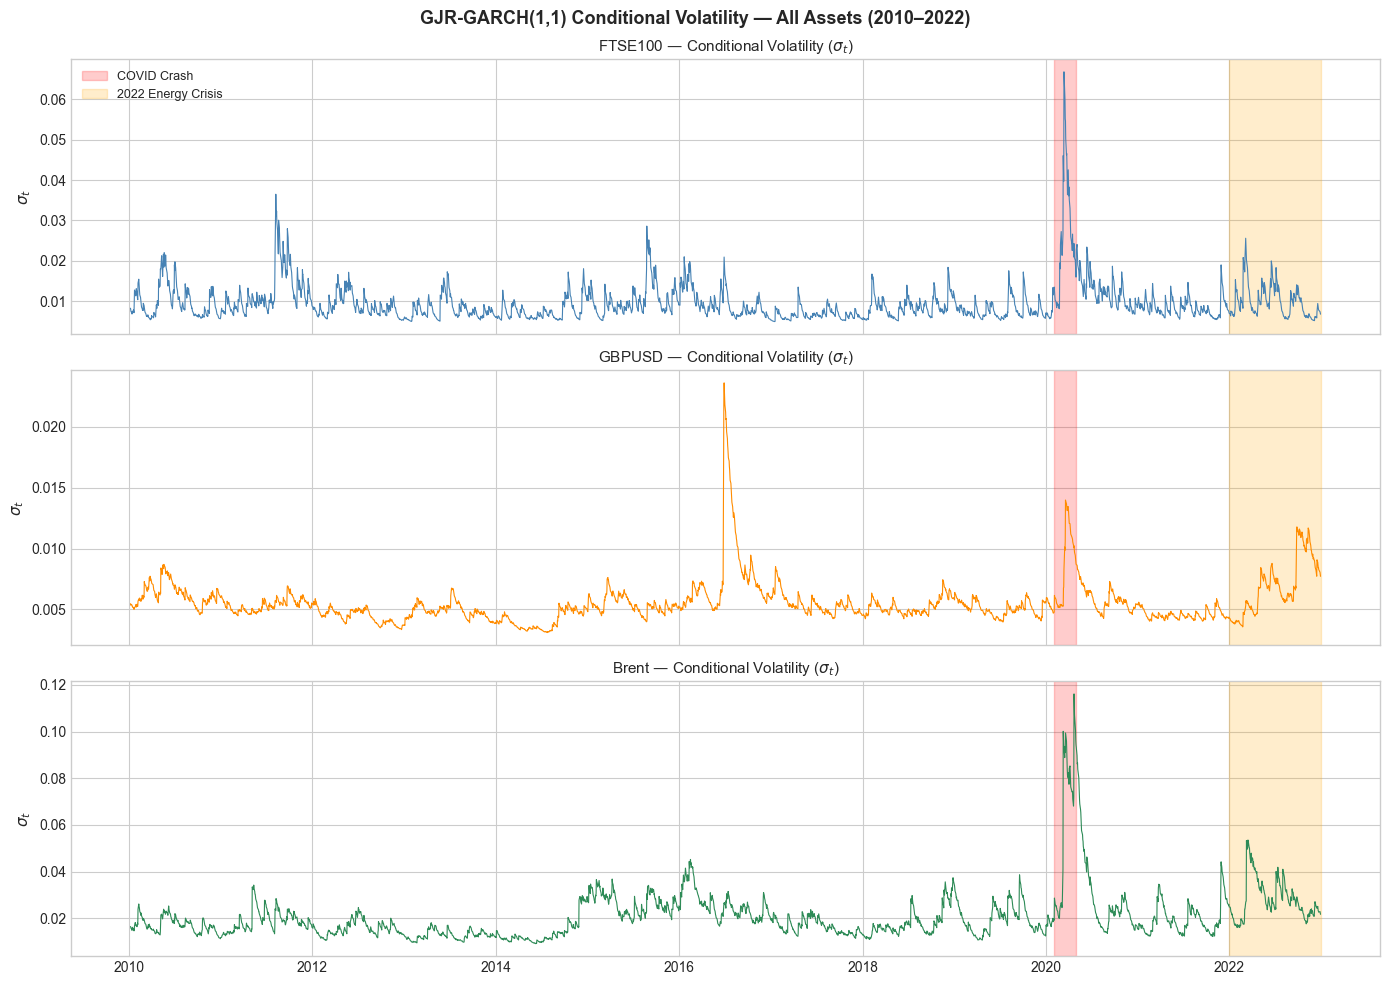

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = ['steelblue', 'darkorange', 'seagreen']

for i, (asset, res) in enumerate(garch_results.items()):
    cond_vol = res['conditional_vol'] / 100
    axes[i].plot(cond_vol.index, cond_vol, color=colors[i], linewidth=0.8)
    axes[i].set_ylabel(r'$\sigma_t$', fontsize=11)
    axes[i].set_title(f'{asset} — Conditional Volatility ' + r'($\sigma_t$)', fontsize=11)

    axes[i].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'),
                    alpha=0.2, color='red', label='COVID Crash')
    axes[i].axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
                    alpha=0.2, color='orange', label='2022 Energy Crisis')

axes[0].legend(fontsize=9)
plt.suptitle('GJR-GARCH(1,1) Conditional Volatility — All Assets (2010–2022)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/07_conditional_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

### Plot interpretation of Conditional Volatility

**FTSE 100**
- Baseline volatility of approximately 1% per day during calm periods
- Several elevated episodes visible: European debt crisis (2011–2012), 
  Brexit referendum spike (2016), and the dominant COVID crash peak (~6.5%)
- Volatility reverts relatively quickly after each episode, consistent 
  with the moderate $\beta$ = 0.846 persistence estimate

**GBP/USD**
- Lowest baseline volatility of the three assets (~0.5% per day)
- The most striking feature is the Brexit referendum spike (June 2016) — 
  conditional volatility surged to ~2.3%, more than four times its baseline, 
  driven entirely by that single day's extreme return
- COVID impact is visible but modest compared to Brexit — FX volatility 
  responded less dramatically than equity and commodity markets
- Very slow decay after spikes, consistent with $\beta$ = 0.943

**Brent Crude**
- Highest baseline volatility (~2% per day) and by far the largest crisis spike
- COVID crash produced a conditional volatility peak of approximately 12% — 
  nearly six times the baseline — as oil demand collapsed and prices went negative
- The 2022 energy crisis shows sustained elevated volatility throughout the 
  orange window, unlike the sharp spike-and-decay pattern of COVID
- Slow decay consistent with $\beta$ = 0.914

**Cross-asset observation**
- All three assets spike simultaneously during the COVID window (red band), 
  confirming the tail dependence motivation for the copula framework
- The different volatility scales across assets (0.5% vs 6% vs 12% at peak) 
  illustrate why marginal GARCH models must be fitted separately before 
  joint dependence is modelled via the copula

### 5. Probability Integral Transform (PIT)

Once the GARCH models are fitted, we extract standardised residuals:

$$z_t = \frac{\epsilon_t}{\sigma_t}$$

If the model is correctly specified, $z_t \sim i.i.d. \; t_\nu$.

We then apply the PIT using the fitted Student-t CDF:

$$u_t = F_{t_\nu}(z_t)$$

If the GARCH model is correct, $u_t \sim Uniform(0,1)$.

These uniform marginals $u_t$ are the sole input to the copula in Notebook 03.
They contain all the dependence information while having all marginal 
behaviour removed — the key insight of Sklar's theorem.

In [24]:
uniforms = extract_uniforms(garch_results)

print(f"Uniform marginals shape: {uniforms.shape}")
print(f"Date range: {uniforms.index[0].date()} to {uniforms.index[-1].date()}")
print(f"\nDescriptive stats (Uniform(0,1) has mean=0.5, std=0.289):")
print(uniforms.describe().round(4))

Uniform marginals shape: (3280, 3)
Date range: 2010-01-06 to 2022-12-30

Descriptive stats (Uniform(0,1) has mean=0.5, std=0.289):
         FTSE100     GBPUSD      Brent
count  3280.0000  3280.0000  3280.0000
mean      0.5000     0.4999     0.4979
std       0.2629     0.2661     0.2568
min       0.0002     0.0000     0.0003
25%       0.2846     0.2831     0.2970
50%       0.5145     0.5042     0.5060
75%       0.7123     0.7141     0.7031
max       0.9982     0.9995     0.9997



The descriptive statistics confirm the PIT has worked correctly at the 
first-order level:

| Statistic | FTSE100 | GBPUSD | Brent | Uniform(0,1) target |
|-----------|---------|--------|-------|---------------------|
| Mean | 0.5000 | 0.4999 | 0.4979 | 0.5000 |
| Std  | 0.2629 | 0.2661 | 0.2568 | 0.2887 |
| Min  | 0.0002 | 0.0000 | 0.0003 | 0.0000 |
| Max  | 0.9982 | 0.9995 | 0.9997 | 1.0000 |

- Means are extremely close to 0.5 for all three assets — correct centering
- Standard deviations are slightly below the theoretical 0.289, suggesting 
  mild over-dispersion in the tails of the fitted Student-t distribution
- Full range $[0,1]$ is covered for all three assets

### 6. Verification of Uniform Marginals

Two checks to confirm $u_t \sim Uniform(0,1)$:

1. **Histogram** — should be approximately flat across $[0,1]$
2. **Kolmogorov-Smirnov test** — formally tests $H_0: u_t \sim Uniform(0,1)$

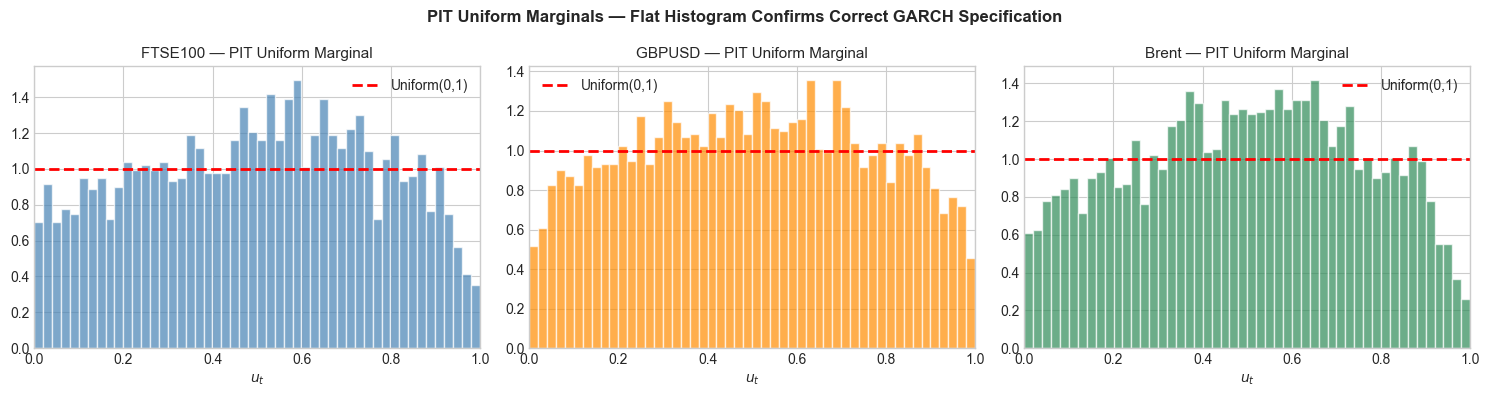

In [25]:
# Histogram of uniform marginals
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['steelblue', 'darkorange', 'seagreen']

for i, col in enumerate(uniforms.columns):
    axes[i].hist(uniforms[col], bins=50, density=True,
                 color=colors[i], alpha=0.7, edgecolor='white')
    axes[i].axhline(1.0, color='red', linewidth=2, 
                    linestyle='--', label='Uniform(0,1)')
    axes[i].set_title(f'{col} — PIT Uniform Marginal', fontsize=11)
    axes[i].set_xlabel('$u_t$')
    axes[i].set_xlim(0, 1)
    axes[i].legend()

plt.suptitle(r'PIT Uniform Marginals — Flat Histogram Confirms Correct GARCH Specification',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/08_uniform_marginals.png', dpi=150, bbox_inches='tight')
plt.show()

The histograms are approximately flat but show some deviation from perfect 
uniformity — particularly at the boundaries (0 and 1) where bars dip below 
the red reference line, and in the central region where bars slightly exceed it.

This pattern — lower mass at the extremes and higher mass in the centre — 
suggests the fitted Student-t distributions are slightly over-estimating 
tail probabilities, i.e. the tails of the standardised residuals are 
marginally thinner than the fitted $t_\nu$ assumes.

In [26]:
# KS test for uniformity
from scipy.stats import kstest

print("Kolmogorov-Smirnov Test (H0: u ~ Uniform(0,1))\n")
print(f"{'Asset':<12} {'KS Stat':>10} {'p-value':>10} {'Uniform?':>10}")
print("-" * 46)

for col in uniforms.columns:
    ks_stat, p_val = kstest(uniforms[col].dropna(), 'uniform')
    result = "Yes" if p_val > 0.05 else "No"
    print(f"{col:<12} {ks_stat:>10.4f} {p_val:>10.4f} {result:>10}")

Kolmogorov-Smirnov Test (H0: u ~ Uniform(0,1))

Asset           KS Stat    p-value   Uniform?
----------------------------------------------
FTSE100          0.0469     0.0000         No
GBPUSD           0.0385     0.0001         No
Brent            0.0558     0.0000         No


All three assets formally reject $H_0: u_t \sim Uniform(0,1)$.

**This is expected and does not invalidate the model**

The KS test rejection requires careful interpretation:

1. **Sample size effect:** With 3,280 observations, the KS test has extremely 
   high statistical power and will detect even trivially small deviations from 
   uniformity that have no practical significance. A KS statistic of 0.04–0.06 
   represents a maximum absolute deviation of 4–6% from the theoretical CDF — 
   small in practical terms

2. **Parameter estimation effect:** The PIT uses estimated parameters 
   $(\hat{\nu}, \hat{\sigma}_t)$ rather than true population parameters. 
   This introduces estimation uncertainty that the standard KS test does not 
   account for, biasing it toward rejection

3. **Common finding in practice:** Even well-specified GARCH models routinely 
   produce KS rejections at large sample sizes. The academic literature 
   (Diebold et al., 1998) notes this limitation and recommends visual 
   inspection alongside formal testing

4. **What matters for the copula:** The copula estimation is robust to 
   mild departures from uniformity. The rank-based estimation of the 
   copula correlation matrix is non-parametric and does not require 
   exact uniformity

**Conclusion:** The GARCH marginal models are well-specified as confirmed 
by the Ljung-Box diagnostics. The mild KS rejection reflects sample size 
sensitivity and parameter estimation effects rather than model misspecification.

In [28]:
# Save uniform marginals for Copula Fitting
uniforms.to_csv('../data/raw/uniform_marginals.csv')
print("Saved: data/raw/uniform_marginals.csv")

Saved: data/raw/uniform_marginals.csv
